## Calculating the energy consumption of the English Housing Stock using CUBES with data from Tabula and Hotmaps

### Importing modules

In [1]:
from cubes.construct import building
from cubes.construct import sample
from cubes.construct.extractor import Extractor
from cubes.construct import constants
from cubes.construct.building import Building
from cubes.package.simple_simulation import prepare_simulation
from cubes.package import envconfig
from geomeppy import IDF
import pandas as pd

import os
from pathlib import Path

### Defining methods

SyntaxError: invalid syntax (3033048391.py, line 1)

In [ ]:
def test_specific_idf(building_code):
    geometry_data = constants.raw_geometry_data[constants.raw_geometry_data['REFERENCE BUILDING CODE'] == building_code]
    systems_data =constants.clean_system_data[constants.clean_system_data['Building typology'] == building_code]

    geometry_data = geometry_data.reset_index(drop = True)
    extracted = Extractor(geometry_data, systems_data)

    BC = extracted.create_building_config_object()
    EC = envconfig.EnvConfig(observe_zone_temperature=True,observe_electricity_demand=True,observe_outside_temperature=True)    
    building=Building(BC)
    building.build()
    idf = building.get_idf()

    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf,weather_file=prepare_simulation(idf,BC,EC)
    
    idf.save(filename=env_data_path + "/test1.idf")
    print(weather_file)
    idf.run(
        expandobjects=True,
        readvars=True,
        weather=weather_file,
        output_directory=output_directory_path,
)


def run_archetypes(codes):
    data = {'Code': [], 'Energy': []}

    for code in codes:
        test_specific_idf(code)
        ht = pd.read_html("/workspaces/CUBES/exp/jack/EHS-energy-comparison/input_case_1/output/eplustbl.htm")[0]
        energy = ht.iloc[1,1]
        data['Code'].append(code)
        data['Energy'].append(energy)

    df = pd.DataFrame(data)

    return df

#### Getting the English Archetype codes

In [ ]:
#gb_ambience = pd.read_excel('/workspaces/CUBES/exp/jack/Data/UK_Data/GB_Ambience.xlsx')
num_buildings = constants.gb_ambience['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
gb_codes = constants.gb_ambience.iloc[:,1]

Cement fiber slabs shredded wood
Asbestos fibre
Perlite board expanded
Rock wool
Urea formaldehyde resin foam
Mineral wool
Polystyrene expanded
Polyurethane foam
Polyisocyanurate aged with facers
Concrete block (dense) (exposed)
Concrete block (dense) (protected)
Precast concrete (dense) (exposed)
Precast concrete (dense) (protected)
Cast concrete 2000
Cast concrete 1800
Brick fired clay 2400
Brick fired clay 2240
Brick fired clay 2080
Brick fired clay 1920
Brick fired clay 1600
Brick fired clay 1280
Brick fired clay 1120
Basalt
Granite red
Sandstone
Limestone
Sandstone tiles
Oak beech ash walnut
Maple oak and similar hardwoods
Timber
Singh_pInsulation
Singh_roof_insulation
Singh_roof_structure
Singh_wall_plasterlayer
Singh_wall_insulation
Singh_wall_structure
Singh_floor_structure
Singh_gfloor_insulation
Singh_floor_cementscreed
Singh_ifloor_insulation
Singh_plasterboard
Singh_iwall_insulation
Singh_roof_plaster
Singh_Internal_Material
Paton_cast_concrete
Paton_timber_floor
Paton_carp

### Running the simulations on the English Housing Stock
The annual energy consumption and code is stored within a dataframe, df

In [ ]:
df = run_archetypes(gb_codes)

GB-AB-03


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/CUBES/src/cubes/data/weather/cambridge_lat=52.25_lng=0.25_period=2021.epw'

#### Adding information to the dataframe
Information like the number of buildings, total energy consumption and tabula's estimate

In [ ]:
df = pd.concat([df, num_buildings], axis=1)
df['Energy'] = pd.to_numeric(df['Energy'])
df['Total Energy'] = df['Energy']*df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']

In [ ]:
tabula = {'Floor_Area / m2':[3362, 4357, 4045, 425, 481, 447, 559, 633, 693, 994, 994,
                             198, 153, 134, 123, 127, 141, 149, 149, 105, 93, 88, 85, 
                             74, 80, 98, 98], 
                             
        'Primary_Energy / kWh/m2' :[387.8, 307.9, 78.3, 423.5, 441.1, 437.8, 375.7, 
                                    318.7, 306.9, 89.8, 84.6, 228.3, 233.5, 231.7, 
                                    221.6, 194.6, 180.0, 97.6, 92.9, 238.5, 246.5, 
                                    238.6, 218.9, 205.9, 198.6, 99.4, 94.1]}

tabula_df = pd.DataFrame(tabula)

In [ ]:
tabula_df['Total Energy / kWh'] = (tabula_df['Floor_Area / m2']*tabula_df['Primary_Energy / kWh/m2'])
tabula_df['num_buildings'] = df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
tabula_df['stock_energy_estimate'] = tabula_df['Total Energy / kWh']*tabula_df['num_buildings']

df['Tabula Estimate'] = tabula_df['stock_energy_estimate']
df['cumsum_Tabula'] = df['TABULA / TWh'].cumsum()
df['cumsum_CUBES'] = df['CUBES / TWh'].cumsum()
df['Total Energy / kWh'] = df['Total Energy']*277.8

df = df.rename(columns ={'Energy':'Energy / GJ','Total Energy': 'CUBES / GJ','Total Energy / kWh': 'CUBES / TWh', 'Tabula Estimate': 'TABULA / TWh'})


In [ ]:
cwd_path = os.getcwd()
output_directory_path = os.path.join(cwd_path, "results")
df.to_csv('/workspaces/CUBES/exp/jack/EHS-energy-comparison/results/cubes_tabula_comparison.csv')

#### Importing previously determined results

In [ ]:
df = pd.read_csv('/workspaces/CUBES/exp/jack/Data/cubes_tabula_comparison.csv')

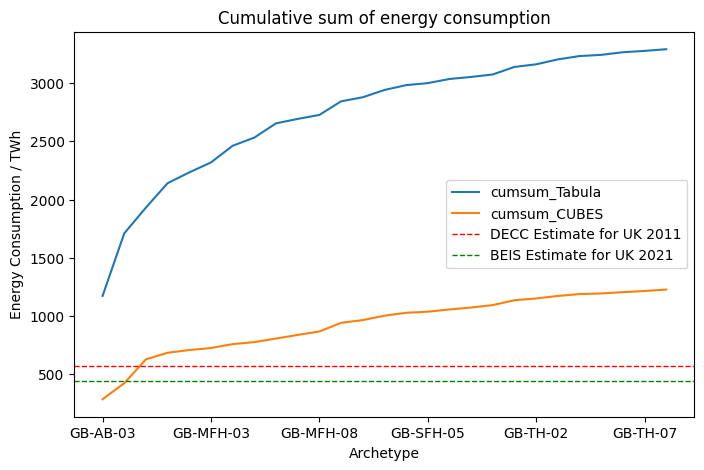

In [ ]:
plot = df.plot.line(x='Code', y=['cumsum_Tabula', 'cumsum_CUBES'], figsize=(8,5))
plot.axhline(y=571, color= 'red', linewidth=1, linestyle='--', label="DECC Estimate for UK 2011")
plot.axhline(y=438, color= 'green', linewidth=1, linestyle='--', label="BEIS Estimate for UK 2021")
plot.set_title('Cumulative sum of energy consumption')

plot.set_ylabel('Energy Consumption / TWh')
plot.set_xlabel('Archetype')
plot.legend()



Text(0.5, 1.0, 'Comparison between CUBES and Tabula archetype energy consumption')

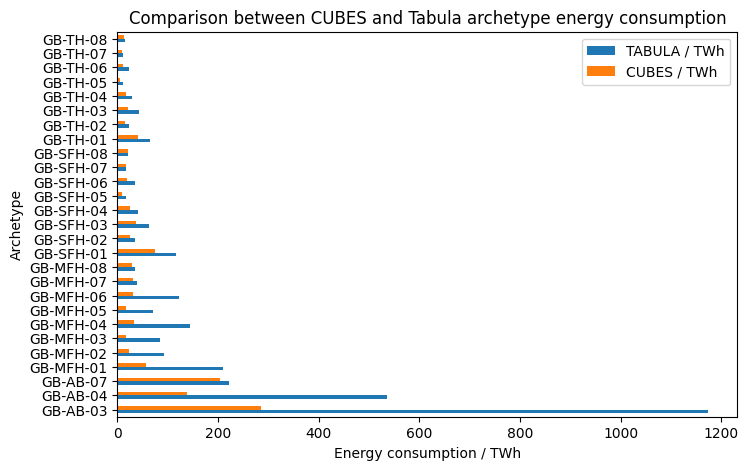

In [ ]:
sp = df.plot.barh(x='Code', y=['TABULA / TWh', 'CUBES / TWh'], figsize=(8,5))
sp.set_xlabel('Energy consumption / TWh')
sp.set_ylabel('Archetype')
sp.set_title('Comparison between CUBES and Tabula archetype energy consumption')